### Goal: collect sequences of essential enzymes across many organisms. 

In [7]:
import requests
import time
import csv
import re
from typing import Dict, List, Optional

def kegg_get(url: str, max_retries: int = 3) -> Optional[str]:
    """Fetch data from KEGG API with retry logic."""
    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                return response.text
            elif response.status_code == 404:
                return None
            else:
                print(f"HTTP {response.status_code} for {url}, attempt {attempt + 1}")
                time.sleep(1)
        except requests.RequestException as e:
            print(f"Request failed for {url}: {e}, attempt {attempt + 1}")
            time.sleep(1)
    
    print(f"Failed to fetch {url} after {max_retries} attempts")
    return None

def get_genes_for_ko_in_organism(org_code: str, ko_id: str) -> List[str]:
    """Get list of gene IDs for a KO in a specific organism."""
    url = f"http://rest.kegg.jp/link/{org_code}/{ko_id}"
    result = kegg_get(url)
    
    if not result:
        return []
    
    gene_ids = []
    for line in result.strip().split('\n'):
        if line.strip():
            # Line format: ko:KXXXXX\torg:gene_id
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                gene_id = parts[1].split(':')[-1]  # Extract gene ID after last colon
                gene_ids.append(gene_id)
    
    return gene_ids

def get_gene_sequence(gene_id: str) -> Optional[str]:
    """Get nucleotide sequence for a gene ID."""
    url = f"http://rest.kegg.jp/get/{gene_id}/ntseq"
    result = kegg_get(url)
    
    if not result:
        return None
    
    # Parse FASTA format - extract sequence only
    lines = result.strip().split('\n')
    sequence_lines = []
    in_sequence = False
    
    for line in lines:
        if line.startswith('>'):
            in_sequence = True
            continue
        if in_sequence and line.strip():
            sequence_lines.append(line.strip())
    
    return ''.join(sequence_lines) if sequence_lines else None

def clean_sequence(seq: str) -> str:
    """Clean sequence by removing whitespace and converting to uppercase."""
    if seq is None:
        return ""
    return re.sub(r'\s+', '', seq).upper()

def build_gene_table(
    organisms: List[str], 
    kos: Dict[str, str],
    output_file: str = "gene_sequences.csv",
    delay: float = 0.5,
    max_genes_per_ko: int = 1
):
    """
    Build a CSV table with organisms as rows and genes as columns.
    
    Parameters:
    - organisms: List of KEGG organism codes (e.g., ['eco', 'pae'])
    - kos: Dictionary mapping column names to KO IDs (e.g., {'16S': 'K01977'})
    - output_file: Output CSV filename
    - delay: Delay between API calls to be respectful to KEGG servers
    - max_genes_per_ko: How many gene copies to include (1 = first copy only)
    """
    
    # Prepare CSV header
    fieldnames = ['organism'] + list(kos.keys())
    
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        
        for i, org in enumerate(organisms, 1):
            print(f"Processing organism {i}/{len(organisms)}: {org}")
            
            row_data = {'organism': org}
            
            for gene_name, ko_id in kos.items():
                print(f"  Fetching {gene_name} ({ko_id}) for {org}")
                
                # Get gene IDs for this KO in this organism
                gene_ids = get_genes_for_ko_in_organism(org, ko_id)
                
                if gene_ids:
                    sequences = []
                    # Get up to max_genes_per_ko sequences
                    for gene_id in gene_ids[:max_genes_per_ko]:
                        full_gene_id = f"{org}:{gene_id}"
                        seq = get_gene_sequence(full_gene_id)
                        if seq:
                            sequences.append(clean_sequence(seq))
                        time.sleep(delay)  # Be nice to KEGG servers
                    
                    if sequences:
                        # Join multiple sequences with '||' separator if multiple copies
                        row_data[gene_name] = ' || '.join(sequences) if len(sequences) > 1 else sequences[0]
                    else:
                        row_data[gene_name] = "Sequence retrieval failed"
                else:
                    row_data[gene_name] = "Gene not found"
                
                time.sleep(delay)  # Rate limiting
            
            writer.writerow(row_data)
            print(f"  Completed {org}")
            print("-" * 50)
    
    print(f"Table saved to {output_file}")


# Define your organisms (KEGG organism codes)
organisms = [
    # === Original core set ===
    'eco',   # Escherichia coli (facultative anaerobe, partial denitrifier)
    'pae',   # Pseudomonas aeruginosa (classic denitrifier)
    'bja',   # Bradyrhizobium japonicum (symbiotic N2-fixer, can denitrify)
    'mtu',   # Mycobacterium tuberculosis (actinobacterial pathogen, not a denitrifier)
    'sco',   # Streptomyces coelicolor (soil actinomycete, diverse secondary metabolism)

    # === Pseudomonas & close relatives (strong denitrifiers) ===
    'ppu',   # Pseudomonas putida (soil denitrifier, bioremediation)
    'pfl',   # Pseudomonas fluorescens (plant-associated denitrifier)
    'pcr',   # Pseudomonas chlororaphis (biocontrol agent, denitrifies)
    'pmh',   # Pseudomonas mendocina (aerobic denitrifier)
    'pps',   # Pseudomonas stutzeri (versatile denitrifier, model for N2O reduction)
    'pam',   # Pseudomonas aeruginosa M18 (rhizosphere strain)
    'paq',   # Pseudomonas aeruginosa UCBPP-PA14 (clinical isolate, full denitrification)
    'rso',   # Ralstonia solanacearum (plant pathogen, denitrifier)
    'ctu',   # Cupriavidus necator (H2-oxidizing, denitrifying betaproteobacterium)
    'par',   # Paracoccus denitrificans (model complete denitrifier)
    'hde',   # Halomonas denitrificans (moderately halophilic denitrifier)
    'mxa',   # Methylobacterium extorquens (methylotroph, denitrifies under hypoxia)
    'rej',   # Rhodopseudomonas palustris (photosynthetic, denitrifies, degrades aromatics)
    'bxe',   # Burkholderia xenovorans (pollutant degrader, denitrifier)
    'bma',   # Burkholderia mallei (pathogen, partial denitrifier)
    'bce',   # Bacillus cereus (some strains denitrify anaerobically)
    'gme',   # Geobacter metallireducens (metal reducer, uses nitrate as electron acceptor)
    'dha',   # Denitrobacterium detoxificans (rumen denitrifier)
    'aeh',   # Aromatoleum aromaticum (anaerobic denitrifier, degrades aromatics)
    'vpa',   # Vibrio parahaemolyticus (marine denitrifier)
    'vch',   # Vibrio cholerae (some strains denitrify)
    'son',   # Shewanella oneidensis (metal reducer, uses nitrate/nitrite)
    'sfr',   # Shewanella frigidimarina (psychrophilic denitrifier)

    # === Alpha-proteobacteria (many diazotrophs & denitrifiers) ===
    'bja',   # Bradyrhizobium japonicum (already listed; symbiotic N2-fixer + denitrifier)
    'bju',   # Bradyrhizobium diazoefficiens (similar to bja)
    'rhc',   # Rhodobacter capsulatus (photosynthetic, denitrifies)
    'rbd',   # Rhodobacter sphaeroides (purple non-sulfur bacterium, denitrifier)
    'azo',   # Azotobacter vinelandii (free-living N2-fixer, reduces nitrate)
    'mlo',   # Mesorhizobium loti (symbiotic N2-fixer, some denitrification genes)
    'rpa',   # Rhodopseudomonas palustris TIE-1 (photoferrotroph, denitrifies)
    'mag',   # Magnetospirillum magneticum (microaerophilic, denitrifies)
    'cau',   # Caulobacter crescentus (oligotroph, partial denitrification)
    'sil',   # Sinorhizobium meliloti (alfalfa symbiont, has napA but limited denitrification)

    # === Beta-proteobacteria (many complete denitrifiers) ===
    'tpo',   # Thiocapsa pfennigii (purple sulfur phototroph, denitrifier)
    'nme',   # Nitrosomonas europaea (ammonia oxidizer, not denitrifier – for N-cycle contrast)
    'nwi',   # Nitrosospira winogradskyi (soil ammonia oxidizer)
    'npc',   # Nitrosomonas sp. CPD (ammonia oxidizer)
    'ade',   # Alcaligenes faecalis (complete denitrifier, N2O reducer)
    'dse',   # Desulfovibrio vulgaris (sulfate reducer – metabolic contrast, may reduce nitrate)
    'ddn',   # Dechloromonas aromatica (denitrifying, dechlorinates)
    'ttu',   # Thauera terpenica (denitrifying, degrades terpenes)
    'bae',   # Bordetella avium (pathogen, partial denitrifier)

    # === Gamma-proteobacteria (diverse metabolisms) ===
    'ent',   # Enterobacter cloacae (opportunistic pathogen, denitrifier)
    'esa',   # Cronobacter sakazakii (formerly Enterobacter, partial denitrifier)
    'kpn',   # Klebsiella pneumoniae (N2-fixer, denitrifier)
    'cko',   # Citrobacter koseri (clinical isolate, denitrifies)
    'spe',   # Serratia proteamaculans (plant-associated, denitrifier)
    'srr',   # Serratia marcescens (opportunistic pathogen, denitrifier)
    'ame',   # Aeromonas hydrophila (aquatic, denitrifies)
    'xoo',   # Xanthomonas oryzae (plant pathogen, partial denitrification)
    'xcc',   # Xanthomonas campestris (similar to xoo)
    'psa',   # Pectobacterium atrosepticum (soft rot pathogen, denitrifies)

    # === Delta/Epsilon-proteobacteria ===
    'wbr',   # Wolinella succinogenes (epsilonproteobacterium, reduces nitrate)
    'hpy',   # Helicobacter pylori (pathogen, reduces nitrate to ammonia)
    'btr',   # Bdellovibrio bacteriovorus (predatory, partial denitrification)
    'mcp',   # Myxococcus xanthus (deltaproteobacterium, soil predator, has narG)

    # === Firmicutes (some denitrify, mostly fermenters) ===
    'bce',   # Bacillus cereus (already listed; some strains denitrify)
    'bcl',   # Bacillus clausii (alkaliphile, may reduce nitrate)
    'bth',   # Bacillus thuringiensis (insect pathogen, denitrifier)
    'lmo',   # Listeria monocytogenes (pathogen, reduces nitrate)
    'lap',   # Lactobacillus plantarum (fermenter – metabolic contrast)
    'sau',   # Staphylococcus aureus (pathogen, reduces nitrate to nitrite only)
    'spy',   # Streptococcus pyogenes (pathogen, no denitrification – contrast)
    'cac',   # Clostridium acetobutylicum (anaerobe, reduces nitrate)

    # === Actinobacteria (high GC, diverse metabolisms) ===
    'sco',   # Streptomyces coelicolor (already listed)
    'mtu',   # Mycobacterium tuberculosis (already listed)
    'mmu',   # Mycobacterium marinum (fish pathogen, similar to mtu)
    'cgl',   # Corynebacterium glutamicum (industrial amino acid producer, reduces nitrate)
    'rfr',   # Rhodococcus fascians (plant pathogen, degrades aromatics, may denitrify)
    'nfa',   # Nocardia farcinica (opportunistic pathogen, aerobic metabolism)

    # === Bacteroidetes ===
    'bfr',   # Bacteroides fragilis (gut commensal, reduces nitrate)
    'pdo',   # Pedobacter saltans (soil bacterium, partial denitrification)
    'fjo',   # Flavobacterium johnsoniae (aquatic, gliding bacterium, has narG)

    # === Cyanobacteria (oxygenic phototrophs, some reduce nitrate) ===
    'syn',   # Synechocystis sp. PCC 6803 (model cyanobacterium, reduces nitrate)
    'slr',   # Synechococcus elongatus PCC 7942 (similar to syn)
    'ava',   # Anabaena variabilis (filamentous, N2-fixer, reduces nitrate)
    'nos',   # Nostoc punctiforme (symbiotic N2-fixer, denitrification genes present)

    # === Additional denitrifiers (from Kyle SI list) ===
    'aaa',   # Acidiphilium cryptum (acidophile, denitrifier)
    'aaci',  # Acidithiobacillus caldus (acidophile, sulfur oxidizer, may reduce nitrate)
    'aalg',  # Algoriphagus sp. (Bacteroidetes, marine)
    'aamb',  # Alteromonas macleodii (marine gammaproteobacterium, denitrifier)
    'aaq',   # Aquifex aeolicus (hyperthermophile, reduces nitrate)
    'aaqi',  # Aquimarina sp. (marine Bacteroidetes)
    'aaqu',  # Arenibacter antarcticus (cold-adapted, may denitrify)
    'aasc',  # Algibacter sp. (marine flavobacterium)
    'aba',   # Acinetobacter baumannii (opportunistic pathogen, denitrifier)
    'abo',   # Acinetobacter oleivorans (hydrocarbon degrader, denitrifies)
    'ace',   # Acidovorax citrulli (plant pathogen, denitrifier)
    'acet',  # Acetobacter pasteurianus (acetic acid bacterium, partial denitrification)
    'achr',  # Acidovorax avenae (plant pathogen, denitrifies)
    'acib',  # Acidobacterium capsulatum (acidobacterium, soil, reduces nitrate)
    'acid',  # Acidithiobacillus ferrooxidans (iron/sulfur oxidizer, reduces nitrate)
    'acii',  # Acidobacterium sp. (soil acidobacterium)
    'acin',  # Acidovorax sp. (beta-proteobacterium, denitrifier)
    'acio',  # Acidovorax ebreus (denitrifying, degrades aromatics)
    'acip',  # Acidovorax bellezanensis (denitrifier)
    'acis',  # Acidovorax sp. JS42 (nitroaromatic degrader, denitrifies)
    'ack',   # Akkermansia muciniphila (gut symbiont, reduces nitrate)
    'acom',  # Acidovorax communis (soil denitrifier)
    'acr',   # Acidithiobacillus ferrivorans (psychrotolerant iron oxidizer)
    'acra',  # Acidiphilium rubrum (acidophile, phototrophic, denitrifies)
    'acry',  # Acidovorax cryoconiti (glacier isolate, denitrifier)
    'acto',  # Actinobacillus suis (pathogen, reduces nitrate)
    'actt',  # Actinobacillus pleuropneumoniae (pathogen, partial denitrification)
    'acu',   # Acidovorax temperans (denitrifier)
    'adi',   # Arthrobacter aurescens (soil actinobacterium, degrades atrazine)
    'adk',   # Arthrobacter sp. (soil, diverse metabolism)
    'adn',   # Anaeromyxobacter dehalogenans (deltaproteobacterium, reduces nitrate)
    'adt',   # Anaeromyxobacter sp. Fw109-5 (similar to adn)
    'aeb',   # Aequorivita sublithincola (marine flavobacterium)
    'aei',   # Aequorivita sp. (marine)
    'aep',   # Arenimonas maotaiensis (freshwater betaproteobacterium)
    'aev',   # Arenibacter echinorum (marine)
    'aez',   # Arenibacter latericius (marine, may denitrify)
    'afa',   # Afipia birgiae (alpha-proteobacterium, water isolate)
    'afc',   # Afipia clevelandensis (similar to afa)
    'afi',   # Afipia felis (intracellular pathogen)
    'afla',  # Agrobacterium fabrum (plant tumor inducer, reduces nitrate)
    'afq',   # Agrobacterium tumefaciens (similar to afla)
    'agc',   # Agrobacterium sp. H13-3 (soil, motile)
    'agt',   # Agrobacterium vitis (plant pathogen)
    'agv',   # Agromyces aureus (actinobacterium, soil)
    'aht',   # Aminobacter aminovorans (methylotroph, degrades xenobiotics)
    'ahu',   # Aminobacter sp. (soil methylotroph)
    'ahz',   # Aminobacter lissarensis (degrades chloroaromatics)
    'ais',   # Alcanivorax borkumensis (hydrocarbon degrader, marine, denitrifies)
    'aji',   # Alcanivorax jadensis (similar to ais)
    'ajs',   # Alcanivorax dieselolei (oil-degrading, denitrifier)
    'aka',   # Akkermansia glycaniphila (gut symbiont, reduces nitrate)
    'alg',   # Algimonas porphyrae (marine, algal associate)
    'ali',   # Aliivibrio fischeri (symbiotic luminous bacterium, denitrifies)
    'aln',   # Aliivibrio salmonicida (fish pathogen, denitrifier)
    'alp',   # Alteromonas macleodii (duplicate of aamb? keep one)
    'als',   # Alteromonas sp. (marine gammaproteobacterium)
    'alti',  # Altererythrobacter ishigakiensis (marine, aerobic)
    'alv',   # Alteromonas mediterranea (marine, denitrifier)
    'amah',  # Amorphus coralli (coral-associated)
    'amc',   # Amycolatopsis mediterranei (actinobacterium, antibiotic producer)
    'amh',   # Amycolicicoccus subflavus (actinobacterium)
    'ami',   # Amycolatopsis orientalis (vancomycin producer)
    'amih',  # Amycolatopsis sp. (soil actinobacterium)
    'amol',  # Amphibacillus xylanus (alkaliphile, facultative anaerobe)
    'amr',   # Amycolatopsis methanolica (methylotrophic actinobacterium)
    'ams',   # Amycolatopsis sp. ATCC 39116 (soil)
    'amv',   # Amycolatopsis vancoresmycina (antibiotic producer)
    'amyb',  # Amycolatopsis benzoatilytica (degrades benzoate)
    'amyy',  # Amycolatopsis sp. YIM 95256 (soil actinobacterium)
    'ane',   # Anaerocellum thermophilum (thermophilic cellulose degrader)
    'anp',   # Anaerophaga thermohalophila (anaerobic, marine)
    'ant',   # Anaerotruncus colihominis (gut anaerobe)
    'aoa',   # Aurantimonas manganoxydans (manganese oxidizer)
    'aol',   # Aurantimicrobium minutum (freshwater actinobacterium)
    'aon',   # Aurantimonas sp. (marine)
    'aos',   # Aurantimonas sp. TSO31 (manganese oxidizer)
    'apac',  # Arcobacter butzleri (epsilonproteobacterium, reduces nitrate)
    'ape',   # Arcobacter perillensis (similar to apac)
    'apn',   # Arcobacter sp. (water isolate)
    'apoc',  # Arcobacter cloacae (clinical isolate)
    'apom',  # Arcobacter molluscorum (marine)
    'app',   # Arcobacter sp. LMG 24052 (environmental)
    'apre',  # Arcobacter reptans (reptile-associated)
    'aprs',  # Arcobacter sp. F-R1 (freshwater)
    'aqa',   # Aquabacterium commune (beta-proteobacterium, drinking water biofilm)
    'aql',   # Aquabacterium limnoticum (freshwater)
    'aqs',   # Aquaspirillum serpens (microaerophilic, spiral-shaped)
    'arc',   # Arcanobacterium haemolyticum (pathogen, reduces nitrate)
    'arl',   # Arthrobacter arilaitensis (cheese rind, soil)
    'arm',   # Arthrobacter methylotrophus (methylotroph)
    'aro',   # Arthrobacter globiformis (soil, radiation-resistant)
    'art',   # Arthrobacter sp. (ubiquitous soil actinobacterium)
    'artp',  # Arthrobacter psychrolactophilus (psychrotolerant)
    'aru',   # Arthrobacter ureafaciens (urea degrader)
    'ary',   # Arthrobacter sp. YC-12 (soil)
    'asc',   # Asaia bogorensis (acetic acid bacterium, plant-associated)
    'asd',   # Asaia sp. (similar to asc)
    'asip',  # Asaia siamensis (plant endophyte)
    'ask',   # Asaia krungthepensis (similar to asip)
    'asl',   # Asaia lannensis (similar)
    'asv',   # Asticcacaulis excentricus (stalked alpha-proteobacterium)
    'asw',   # Asticcacaulis sp. (similar to asv)
    'ata',   # Aurantimonas sp. TAO31 (manganese oxidizer)
    'atp',   # Aurantimonas sp. TAP31 (similar)
    'atu',   # Agrobacterium tumefaciens (duplicate; already listed as afq)
    'atw',   # Aurantimonas sp. TAW31 (similar)
    'axy',   # Aurantimonas sp. TYX31 (similar)
    'aza',   # Azospirillum brasilense (plant growth-promoting rhizobacterium, N2-fixer, denitrifies)
    'azc',   # Azospirillum lipoferum (similar to aza)
    'azd',   # Azospirillum sp. B510 (similar)
    'azi',   # Azospirillum irakense (similar)
    'azl',   # Azospirillum lipoferum (duplicate)
    'azm',   # Azospirillum amazonense (similar)
    'azo',   # Azotobacter vinelandii (already listed)
    'azq',   # Azorhizobium caulinodans (stem-nodulating N2-fixer, denitrifies)
    'azr',   # Azorhizobium sp. (similar to azq)
    'azt',   # Azotobacter chroococcum (free-living N2-fixer)
    'azz',   # Azotobacter vinelandii (duplicate)

    # === Additional high-quality denitrifiers ===
    'babb',  # Bordetella bronchiseptica (respiratory pathogen, denitrifies)
    'babr',  # Bordetella pertussis (whooping cough, partial denitrification)
    'bac',   # Bacillus anthracis (pathogen, reduces nitrate)
    'bacb',  # Bacillus cereus (duplicate)
    'bacl',  # Bacillus clausii (already listed)
    'baco',  # Bacillus coagulans (thermophile, reduces nitrate)
    'bacp',  # Bacillus pumilus (soil, reduces nitrate)
    'bacs',  # Bacillus subtilis (model organism, reduces nitrate to nitrite)
    'bacy',  # Bacillus cytotoxicus (thermophile)
    'bae',   # Bordetella avium (already listed)
    'bag',   # Bacillus amyloliquefaciens (plant growth-promoting, reduces nitrate)
    'bage',  # Bacillus megaterium (large soil bacillus, denitrifies)
    'bah',   # Bacillus halodurans (alkaliphile, reduces nitrate)
    'bai',   # Bacillus infantis (gut isolate)
    'bao',   # Bacillus oceanisediminis (marine)
    'bapi',  # Bacillus pumilus (duplicate)
    'baq',   # Bacillus aquimaris (marine)
    'bar',   # Bacillus aryabhattai (soil)
    'bast',  # Bacillus stearothermophilus (thermophile)
    'bat',   # Bacillus atrophaeus (surrogate for anthrax)
    'bax',   # Bacillus axarquiensis (soil)
    'bay',   # Bacillus altitudinis (high-altitude)
    'baz',   # Bacillus zhangzhouensis (soil)
    'bbet',  # Bordetella bronchiseptica (duplicate)
    'bbh',   # Bordetella hinzii (avian pathogen, denitrifies)
    'bbm',   # Bordetella muralis (environmental)
    'bbr',   # Bordetella bronchiseptica (duplicate)
    'bbt',   # Bordetella trematum (wound isolate)
    'bby',   # Bordetella bronchiseptica (duplicate)
    'bcad',  # Bacillus cereus (duplicate)
    'bjs',   # Bradyrhizobium japonicum (duplicate)
    'bju',   # Bradyrhizobium diazoefficiens (already listed)
    'bld',   # Bradyrhizobium oligotrophicum (oligotrophic soil)
    'blh',   # Bradyrhizobium elkanii (symbiotic N2-fixer)
    'bli',   # Bradyrhizobium liaoningense (symbiotic)
    'bly',   # Bradyrhizobium yuanmingense (symbiotic)
    'bma',   # Burkholderia mallei (already listed)
    'bmab',  # Burkholderia mallei (duplicate)
    'bmyc',  # Burkholderia mallei (duplicate)
    'bnc',   # Burkholderia cepacia (opportunistic pathogen, denitrifies)
    'boz',   # Burkholderia cepacia (duplicate)
    'bpa',   # Burkholderia pseudomallei (melioidosis agent, denitrifies)
    'bpz',   # Burkholderia pseudomallei (duplicate)
    'bql',   # Burkholderia sp. (environmental)
    'bqy',   # Burkholderia sp. (environmental)
    'bra',   # Bradyrhizobium sp. (symbiotic)
    'bsau',  # Bacillus subtilis (duplicate)
    'bsui',  # Bacillus subtilis (duplicate)
]



kos = {
    # Phylogenetic markers
    'recA': 'K03553',
    'dnaK': 'K04043',
    'fusA': 'K02355',
    '16S': 'K01977',
    # 'gyrB': 'K02469',
    
    # Denitrification
    # 'narG': 'K00370',
    # 'napA': 'K00371',
    # 'nirS': 'K00376',
    # 'nirK': 'K00372',
    # 'norB': 'K04561',
    # 'nosZ': 'K00377',
    # 'nrfA': 'K00379',   # DNRA pathway
    # 'nasA': 'K00378',    # Assimilatory nitrate reductase
    # 'narK': 'K02575',   #nitrate transport
    # 'nirB': 'K00362',   #nitrite reductase
    
    'nifH': 'K02588',
    'amoA': 'K10944',
    
    # # Carbon metabolism
    # 'icd': 'K00031',       # Isocitrate DH
}

# Build the table
build_gene_table(
    organisms=organisms,
    kos=kos,
    output_file="../out/found_genes_2.csv",
    delay=0.5,
        max_genes_per_ko=1
    )

Processing organism 1/249: eco
  Fetching recA (K03553) for eco
  Fetching dnaK (K04043) for eco
  Fetching fusA (K02355) for eco
  Fetching 16S (K01977) for eco
  Fetching nifH (K02588) for eco
  Fetching amoA (K10944) for eco
  Completed eco
--------------------------------------------------
Processing organism 2/249: pae
  Fetching recA (K03553) for pae
  Fetching dnaK (K04043) for pae
  Fetching fusA (K02355) for pae
  Fetching 16S (K01977) for pae
  Fetching nifH (K02588) for pae
  Fetching amoA (K10944) for pae
  Completed pae
--------------------------------------------------
Processing organism 3/249: bja
  Fetching recA (K03553) for bja
  Fetching dnaK (K04043) for bja
  Fetching fusA (K02355) for bja
  Fetching 16S (K01977) for bja
  Fetching nifH (K02588) for bja
  Fetching amoA (K10944) for bja
  Completed bja
--------------------------------------------------
Processing organism 4/249: mtu
  Fetching recA (K03553) for mtu
  Fetching dnaK (K04043) for mtu
  Fetching fusA (K

In [8]:
import pandas as pd
from Bio import pairwise2
from itertools import combinations_with_replacement
import os

# Configuration
INPUT_CSV = "../out/found_genes_2.csv"
OUTPUT_CSV = "../out/pairwise_alignments_2.csv"

# Scoring parameters for nucleotides
MATCH_SCORE = 2
MISMATCH_SCORE = -1
GAP_OPEN = -2
GAP_EXTEND = -0.5

def align_and_score(seq1: str, seq2: str) -> float:
    """Compute global alignment score using simple nucleotide scoring."""
    if not seq1 or not seq2:
        return float('nan')
    
    # Global alignment with simple scoring
    score = pairwise2.align.globalms(
        seq1, seq2,
        MATCH_SCORE, MISMATCH_SCORE,
        GAP_OPEN, GAP_EXTEND,
        score_only=True
    )
    return score

def process_gene_column(gene_name: str, sequences: dict) -> dict:
    """Compute pairwise scores for one gene across all species pairs."""
    results = {}
    species_list = list(sequences.keys())
    
    for sp1, sp2 in combinations_with_replacement(species_list, 2):
        seq1 = sequences[sp1]
        seq2 = sequences[sp2]
        
        # Skip if gene missing or failed
        if seq1 in ["Gene not found", "Sequence retrieval failed"] or \
           seq2 in ["Gene not found", "Sequence retrieval failed"]:
            score = float('nan')
        else:
            score = align_and_score(seq1, seq2)
        
        results[(sp1, sp2)] = score
        if sp1 != sp2:
            results[(sp2, sp1)] = score
    
    return results


df = pd.read_csv(INPUT_CSV, dtype=str)
df = df.fillna("Gene not found")

# Clean empty strings
for col in df.columns:
    if col != 'organism':
        df[col] = df[col].apply(lambda x: "Gene not found" if (isinstance(x, str) and x.strip() == "") else x)

species = df['organism'].tolist()
gene_cols = [col for col in df.columns if col != 'organism']

print(f"Processing {len(species)} species and {len(gene_cols)} genes")

# Build sequence dictionary per gene
gene_sequences = {}
for gene in gene_cols:
    gene_sequences[gene] = dict(zip(df['organism'], df[gene]))

# Generate all species pairs
all_pairs = [(s1, s2) for s1 in species for s2 in species]

# Collect results
output_rows = []
for gene in gene_cols:
    print(f"Aligning {gene}...")
    scores = process_gene_column(gene, gene_sequences[gene])
    for (sp1, sp2) in all_pairs:
        output_rows.append({
            'species_1': sp1,
            'species_2': sp2,
            gene: scores.get((sp1, sp2), float('nan'))
        })

# Pivot to final format
result_df = pd.DataFrame(output_rows)
final_df = result_df.pivot_table(
    index=['species_1', 'species_2'],
    values=gene_cols,
    aggfunc='first'
).reset_index()

final_df.to_csv(OUTPUT_CSV, index=False)
print(f"Done! Saved to {OUTPUT_CSV}")



Processing 249 species and 6 genes
Aligning recA...
Aligning dnaK...
Aligning fusA...
Aligning 16S...
Aligning nifH...
Aligning amoA...
Done! Saved to ../out/pairwise_alignments_2.csv


### Generate Scatter Plots

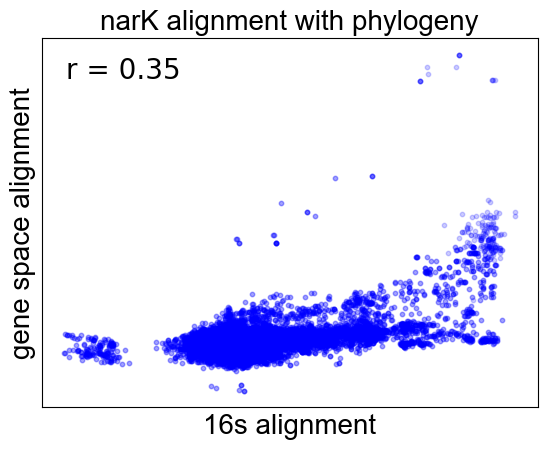

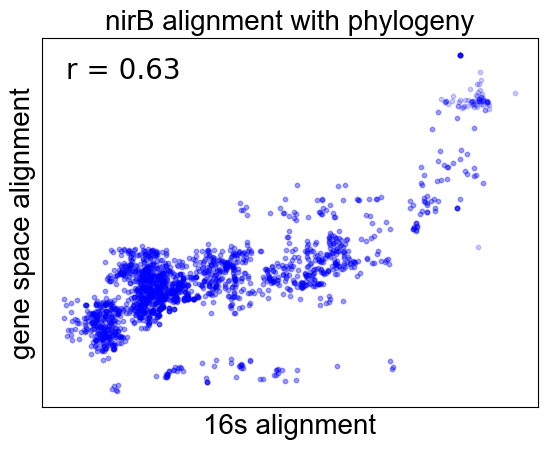

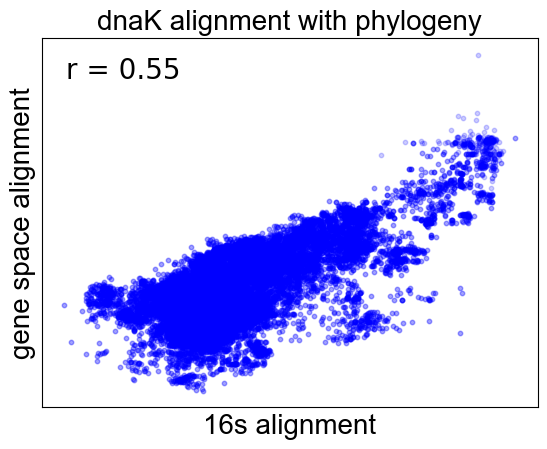

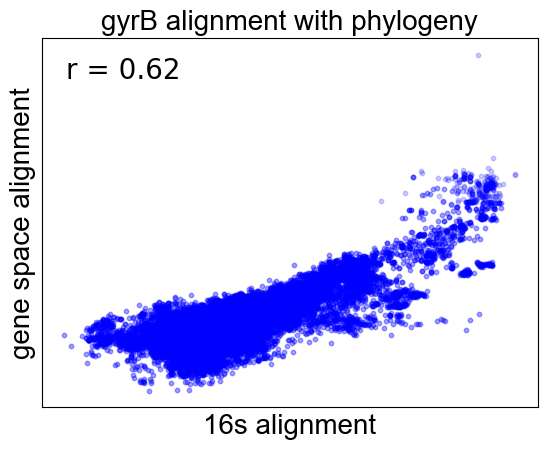

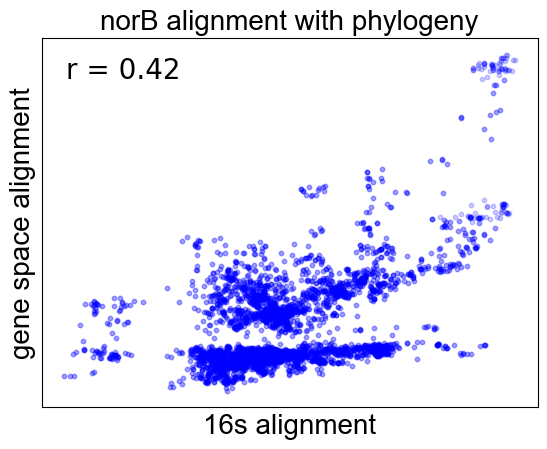

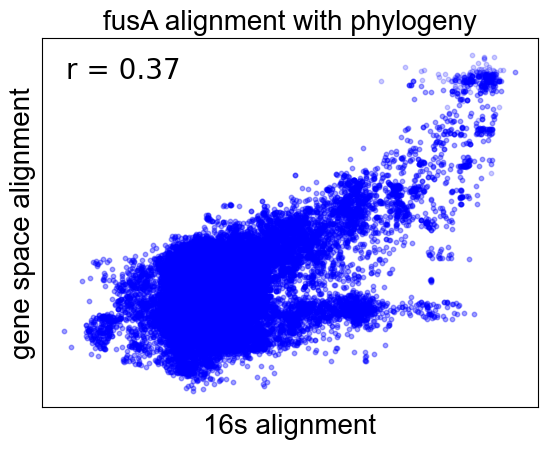

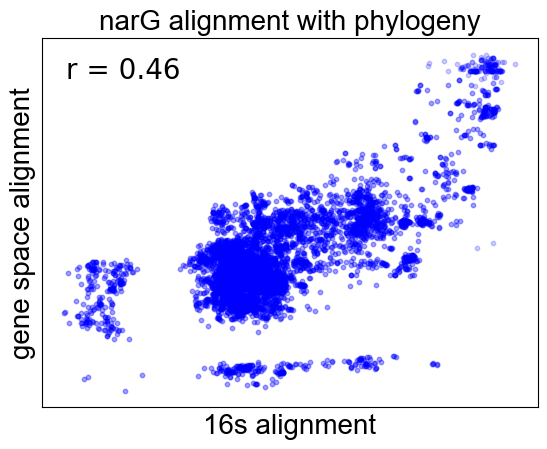

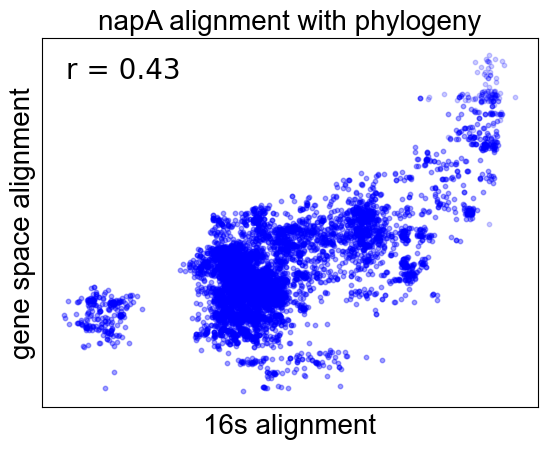

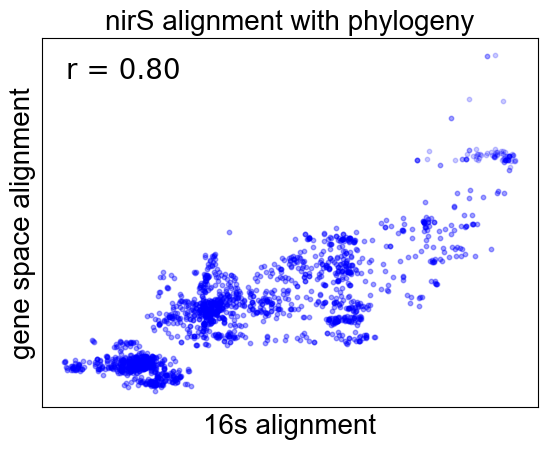

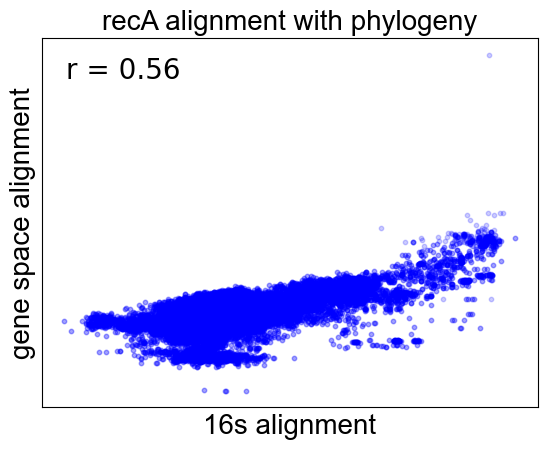

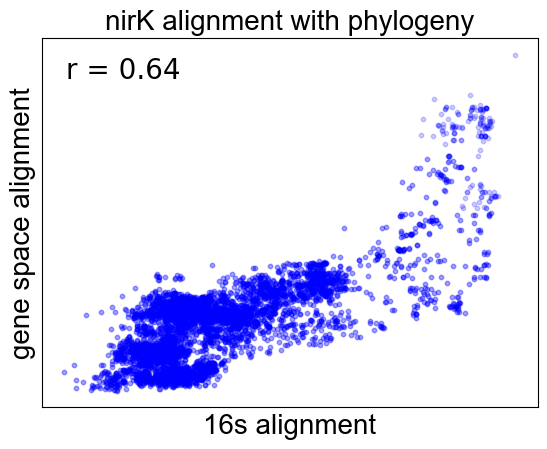

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

alignment_scores = pd.read_csv('../out/pairwise_alignments_combined.csv')


scores_16s = alignment_scores['16S_x'].values


# gene_list = ['cbbL' , 'eno' ,'fbaA' , 'gyrB' , 'icd' , 'napA' , 'narG' , 'nirK' , 'nirS' , 'norB' , 'purA' ,'recA' , 'sdhA' ]


gene_list = {
    # Phylogenetic markers
    'gyrB',
    
    # Denitrification
    'narG',
    'napA',
    'nirS',
    'nirK',
    'norB',
    'narK',
    #'nosZ',
    # #'nrfA',   # DNRA pathway
    # #'nasA',   # Assimilatory nitrate reductase
    # 'narK', #nitrate transport
    'nirB',  #nitrite reductase
    
    # # Carbon metabolism
    # 'icd'      # Isocitrate DH
    'recA',
    'dnaK',
    'fusA',
    # 'nifH',
    # 'amoA',
}

scores = {}

metrics = np.zeros((len(gene_list), 2))


from scipy.stats import spearmanr

import numpy as np
import pandas as pd

def compute_ncs(x, y, n_bins=10):
    """
    Compute Normalized Conditional Standard Deviation (NCS).
    
    NCS = sqrt( E[ Var(y | x_bin) ] ) / std(y)
    
    Parameters:
    - x, y: array-like, same length
    - n_bins: int, number of bins for x (default: 10)
    
    Returns:
    - ncs: float in [0, ~1+]
    """
    x = np.asarray(x)
    y = np.asarray(y)
    
    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    
    # Overall standard deviation of y
    y_std = np.std(y, ddof=1)
    if y_std == 0:
        return 0.0  # y is constant → perfectly defined
    
    # Bin x into quantile-based bins (robust to uneven x distribution)
    bins = pd.qcut(x, q=n_bins, duplicates='drop')
    df = pd.DataFrame({'x': x, 'y': y, 'bin': bins})
    
    # Compute within-bin variances (weighted by bin size)
    bin_stats = df.groupby('bin')['y'].agg(['var', 'count']).dropna()
    
    if bin_stats.empty:
        # Fallback: if too few unique x values
        return np.std(y - np.mean(y)) / y_std  # = 1, but safe
    
    # Weighted average of within-bin variances
    total_n = bin_stats['count'].sum()
    weighted_var = np.average(bin_stats['var'], weights=bin_stats['count'])
    
    # Conditional std = sqrt(weighted average variance)
    cond_std = np.sqrt(weighted_var)
    
    # Normalize
    ncs = cond_std / y_std
    return ncs

for i, gene in enumerate(gene_list):
    scores[f"{gene}"] = alignment_scores[gene].values
    

    # Start with non-NaN pairs
    valid_indices = np.where(~np.isnan(scores_16s) & ~np.isnan(scores[f"{gene}"]))
    gene_scores_valid = scores[f"{gene}"][valid_indices]
    scores_16s_valid = scores_16s[valid_indices]
    
    x_min = 1200 #1200
    x_max = 4000 #3200
    # Further restrict to x-limits: 1200 <= scores_16s <= 3200
    x_limit_mask = (scores_16s_valid >= x_min) & (scores_16s_valid <= x_max)
    gene_scores_plot = gene_scores_valid[x_limit_mask]
    scores_16s_plot = scores_16s_valid[x_limit_mask]

    plt.scatter(scores_16s_plot, gene_scores_plot, color='Blue', alpha=0.2, s=10)
    plt.title(f'{gene} alignment with phylogeny', fontname='arial', fontsize='20')
    plt.xlabel('16s alignment', fontname='arial', fontsize='20')
    plt.ylabel('gene space alignment', fontname='arial', fontsize='20')

    # Compute Pearson r only on points within x-limits
    r, p_value = spearmanr(scores_16s_plot, gene_scores_plot)
    # r = 1 - compute_ncs(scores_16s_plot, gene_scores_plot)
    plt.text(0.05, 0.95, f'r = {r:.2f}', transform=plt.gca().transAxes,
             fontsize=20, verticalalignment='top')
    
    metrics[i, 0] = r

    # plt.xlim(1200, 3200)
    plt.xticks([])
    plt.yticks([])
    # if gene == 'gyrB':
    #     plt.ylim(0, 7000)

    plt.savefig(f'../out/gene_alignments/{gene}.png')
    plt.show()
    
    


### Next, look at gene presence absence

In [19]:
import requests
import time
import csv
import re
import os
from collections import defaultdict

def kegg_get(url, max_retries=3):
    """Fetch data from KEGG API with exponential backoff."""
    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=15)
            if response.status_code == 200:
                return response.text
            elif response.status_code in (400, 404):
                return None
            else:
                time.sleep(1.5 ** attempt)
        except requests.RequestException:
            time.sleep(1.5 ** attempt)
    return None

def fetch_kegg_organisms():
    """Fetch bacterial organisms only."""
    print("🌍 Fetching KEGG organism list...")
    url = "http://rest.kegg.jp/list/organism"
    data = kegg_get(url)
    if data is None:
        raise RuntimeError("Failed to fetch organism list")
    
    organisms = []
    skip_terms = ['virus', 'phage', 'human', 'mouse', 'rat', 'yeast', 'drosophila', 
                  'caenorhabditis', 'arabidopsis', 'zea', 'oryza', 'homo', 'mus', 'plasmid']
    
    for line in data.strip().split('\n'):
        if not line.strip():
            continue
        parts = line.strip().split('\t')
        if len(parts) < 3:
            continue
        
        org_code = parts[1].strip()
        name = parts[2].strip()
        
        if any(term in name.lower() for term in skip_terms):
            continue
        
        organisms.append((org_code, name))
    
    print(f"✅ Retrieved {len(organisms)} bacterial organisms\n")
    return organisms

def extract_species_key(name):
    """Extract normalized species key (genus_species) from KEGG name."""
    clean = re.sub(r'\s*\[.*?\]\s*$', '', name)
    clean = re.sub(r'\s*\([^)]*\)\s*$', '', clean)
    clean = " ".join(clean.split()).strip()
    
    words = clean.split()
    if len(words) >= 2:
        genus = words[0].lower()
        species = words[1].lower()
        if species in ['sp.', 'strain', 'subsp.', 'pv.', 'cf.']:
            if len(words) >= 3:
                species = words[2].lower()
            else:
                return None
        return f"{genus}_{species}"
    return None

def group_strains(organisms):
    """Group strains by flexible species key."""
    groups = defaultdict(list)
    
    for org_code, full_name in organisms:
        strain_hint = ""
        bracket_match = re.search(r'\[(.*?)\]', full_name)
        if bracket_match:
            strain_hint = bracket_match.group(1).strip()
        
        key = extract_species_key(full_name)
        if key:
            groups[key].append((org_code, full_name, strain_hint))
    
    for key in groups:
        groups[key].sort(key=lambda x: (len(x[0]), x[0]))
    
    return groups

def select_diverse_denitrifier_groups(groups, min_strains=2, max_per_species=12, target_total=110):
    """
    Select diverse species groups from denitrifier-relevant taxa.
    Caps strains per species to ensure taxonomic diversity.
    """
    # Expanded list of denitrification-relevant genera (30+)
    denitrifier_genera = {
        # Strong denitrifiers
        'pseudomonas', 'paracoccus', 'thauera', 'achromobacter', 'bordetella',
        'alcaligenes', 'rhodobacter', 'rhodopseudomonas', 'shewanella', 'vibrio',
        'aeromonas', 'enterobacter', 'klebsiella', #'escherichia', 'salmonella',
        'burkholderia', 'ralstonia', 'cupriavidus', 'dechloromonas', 'aromatoleum',
        'acidovorax', 'hydrogenophaga', 'methylobacterium', 'roseobacter',
        # Partial denitrifiers / nitrate reducers
        'bacillus', 'geobacillus', 'paenibacillus', 'bradyrhizobium', 'sinorhizobium',
        'mesorhizobium', 'azospirillum', 'azotobacter',
        # Interesting contrasts (ammonia oxidizers, etc.)
        'nitrosomonas', 'nitrosospira'
    }
    
    # Score species groups
    scored = []
    for key, strains in groups.items():
        if len(strains) < min_strains:
            continue
        
        genus = key.split('_')[0]
        is_denitrifier = genus in denitrifier_genera
        
        # Include denitrifiers OR well-sampled species (for contrast)
        if is_denitrifier or len(strains) >= 8:
            scored.append((key, len(strains), is_denitrifier, strains))
    
    # Sort: denitrifiers first, then by strain count descending
    scored.sort(key=lambda x: (-x[2], -x[1]))
    
    print(f"🔍 Found {len(scored)} species groups with ≥{min_strains} strains in relevant taxa")
    print(f"\nSelecting diverse species (max {max_per_species} strains/species) to reach ~{target_total} total:")
    print(f"{'Species':<30} {'Available':>10} {'Taking':>8} {'Cumulative':>12}")
    print("-" * 65)
    
    selected = {}
    total = 0
    species_count = 0
    
    for key, count, is_denit, strains in scored:
        if total >= target_total * 0.95:
            break
        
        # Cap strains per species for diversity
        take = min(max_per_species, count, target_total - total)
        selected[key] = [s[0] for s in strains[:take]]
        total += take
        species_count += 1
        
        readable = key.replace('_', ' ').title()
        marker = "★" if is_denit else " "
        print(f"{marker} {readable:<28} {count:10d} {take:8d} {total:12d}")
    
    print("-" * 65)
    print(f"✅ Selected {species_count} species groups with {total} total strains\n")
    return selected

def get_description(org_code):
    """Get minimal description from KEGG entry."""
    url = f"http://rest.kegg.jp/get/{org_code}"
    result = kegg_get(url)
    if result is None:
        return ""
    
    comment_match = re.search(r'COMMENT\s+(.+?)(?:\n[A-Z_]+\s+|\Z)', result, re.DOTALL)
    if comment_match:
        lines = [l.strip() for l in comment_match.group(1).split('\n') 
                if l.strip() and 'Comment' not in l]
        if lines:
            return lines[0][:70]
    return ""

def gene_present(org_code, ko_id):
    """Check if gene is present."""
    url = f"http://rest.kegg.jp/link/{org_code}/{ko_id}"
    result = kegg_get(url)
    return 1 if (result and result.strip()) else 0

def build_matrix(species_groups, genes, output_file="../out/denitrifier_variation_2.csv", delay=0.85):
    """Build presence/absence matrix."""
    fieldnames = ['species', 'kegg_org', 'strain', 'description'] + list(genes.keys())
    
    processed = set()
    if os.path.exists(output_file):
        with open(output_file, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                processed.add(row['kegg_org'])
        print(f"♻️  Resuming: {len(processed)} strains already processed\n")
    
    all_strains = []
    for species_key, org_codes in species_groups.items():
        for org_code in org_codes:
            all_strains.append((species_key, org_code))
    
    strain_list = [s for s in all_strains if s[1] not in processed]
    total_target = len(strain_list)
    if total_target == 0:
        print("✅ All strains processed!")
        return
    
    mode = 'a' if os.path.exists(output_file) else 'w'
    write_header = not os.path.exists(output_file)
    
    with open(output_file, mode, newline='', encoding='utf-8') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        if write_header:
            writer.writeheader()
        
        start = time.time()
        for idx, (species_key, org_code) in enumerate(strain_list, 1):
            elapsed = time.time() - start
            remaining = (elapsed / idx * total_target) - elapsed if idx > 0 else 0
            
            print(f"[{idx}/{total_target}] {species_key} ({org_code}) "
                  f"[{elapsed/60:.1f}m elapsed]", end='', flush=True)
            
            url = f"http://rest.kegg.jp/get/{org_code}"
            org_data = kegg_get(url)
            strain_hint = ""
            if org_data is not None:
                name_match = re.search(r'NAME\s+(.+)', org_data)
                if name_match:
                    full_name = name_match.group(1).strip()
                    bracket_match = re.search(r'\[(.*?)\]', full_name)
                    if bracket_match:
                        strain_hint = bracket_match.group(1).strip()[:40]
            
            desc = get_description(org_code)
            time.sleep(delay * 0.3)
            
            row = {
                'species': species_key.replace('_', ' ').title(),
                'kegg_org': org_code,
                'strain': strain_hint,
                'description': desc
            }
            
            symbols = []
            for gene_name, ko_id in genes.items():
                present = gene_present(org_code, ko_id)
                row[gene_name] = present
                symbols.append('✓' if present else '✗')
                time.sleep(delay)
            
            writer.writerow(row)
            csvfile.flush()
            print(f" | {''.join(symbols)}", flush=True)
    
    total_time = time.time() - start
    print(f"\n✅ Completed in {total_time/60:.1f} minutes. Output: {output_file}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print("="*70)
    print("DIVERSE DENITRIFICATION GENE VARIATION ANALYSIS")
    print("Strategy: Cap strains/species to maximize taxonomic diversity")
    print("="*70)
    
    # Fetch and group organisms
    organisms = fetch_kegg_organisms()
    groups = group_strains(organisms)
    
    # Show top groups for diagnostics
    print("📊 Top 20 species groups in KEGG (by strain count):")
    print("-" * 55)
    sorted_groups = sorted(groups.items(), key=lambda x: len(x[1]), reverse=True)
    for key, strains in sorted_groups[:20]:
        print(f"{key.replace('_', ' ').title():<35} {len(strains):3d} strains")
    
    # Select DIVERSE denitrifier groups (cap strains/species)
    selected = select_diverse_denitrifier_groups(
        groups,
        min_strains=3,
        max_per_species=10,   # Critical: cap per species for diversity
        target_total=400
    )
    
    if not selected:
        print("\n❌ No groups found. Try reducing min_strains to 2.")
        exit(1)
    
    # Run analysis
    genes = {
        # 'gyrB': 'K02469',
        # 'icd' : 'K00031',
        # 'narG': 'K00370',   # Membrane nitrate reductase
        # 'napA': 'K00371',   # Periplasmic nitrate reductase
        # 'nirS': 'K00376',   # cd1 nitrite reductase
        # 'nirK': 'K00372',   # Cu nitrite reductase
        # 'norB': 'K04561',   # NO reductase
        # # 'nosZ': 'K00377',   # N2O reductase
        # # 'nrfA': 'K00379',   # DNRA pathway
        # # 'nasA': 'K00378',    # Assimilatory nitrate reductase
        # 'narK': 'K02575',   #nitrate transport
        # 'nirB': 'K00362',   #nitrite reductase
        'recA': 'K03553',
        'dnaK': 'K04043',
        'fusA': 'K02355',
    }
    
    print("\n" + "="*70)
    print("RUNNING GENE PRESENCE ANALYSIS")
    print("="*70)
    build_matrix(selected, genes)

DIVERSE DENITRIFICATION GENE VARIATION ANALYSIS
Strategy: Cap strains/species to maximize taxonomic diversity
🌍 Fetching KEGG organism list...
✅ Retrieved 11057 bacterial organisms

📊 Top 20 species groups in KEGG (by strain count):
-------------------------------------------------------
Chlamydia Trachomatis                73 strains
Escherichia Coli                     66 strains
Helicobacter Pylori                  61 strains
Staphylococcus Aureus                53 strains
Salmonella Enterica                  46 strains
Listeria Monocytogenes               37 strains
Mycobacterium Tuberculosis           34 strains
Wolbachia Endosymbiont               26 strains
Streptococcus Pneumoniae             25 strains
Klebsiella Pneumoniae                24 strains
Campylobacter Jejuni                 23 strains
Acinetobacter Baumannii              22 strains
Pseudomonas Aeruginosa               21 strains
Francisella Tularensis               21 strains
Streptococcus Pyogenes               20

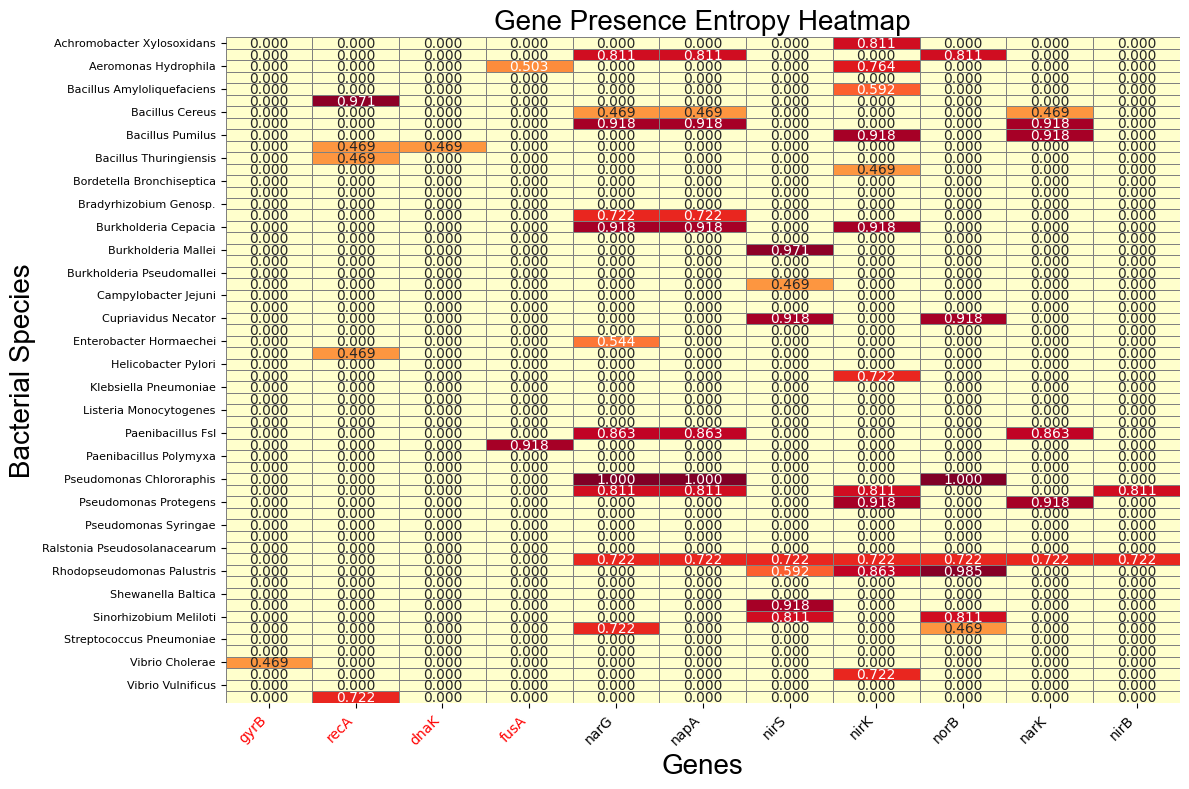

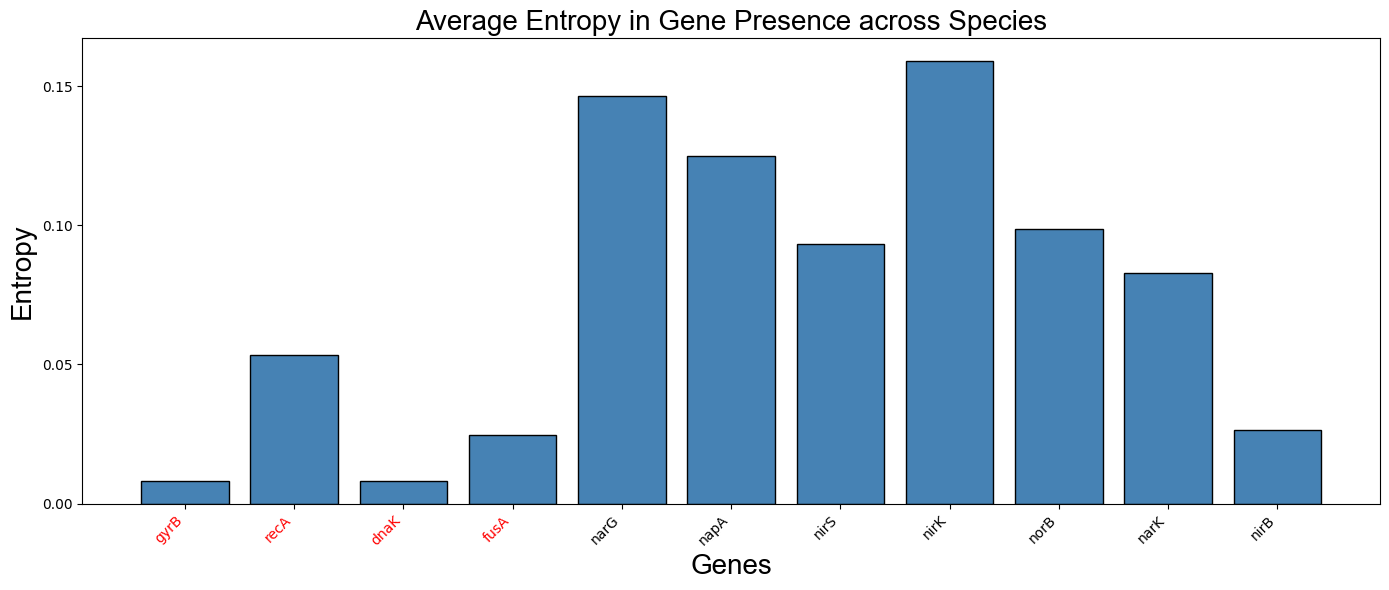

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../out/denitrifier_variation_combined.csv')

# Define gene columns as a LIST to preserve order
gene_cols = [
    'gyrB',
    'narG', 'napA', 'nirS', 'nirK', 'norB', 'narK', 'nirB', 
    'recA', 'dnaK', 'fusA'
]

# select genes that are expected to be related to phylogeny
genes_select = {'gyrB', 'recA', 'dnaK', 'fusA'}  # adjust as needed

# Function to compute binary entropy
def binary_entropy(p):
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# Compute entropy per species
entropy_data = []
for species, group in df.groupby('species'):
    row = {'species': species}
    for gene in gene_cols:
        vals = group[gene].values
        if np.any(~np.isin(vals, [0, 1])):
            raise ValueError(f"Non-binary value found in {species}, {gene}")
        p = np.mean(vals)
        row[gene] = binary_entropy(p)
    entropy_data.append(row)

# Create entropy DataFrame
entropy_df = pd.DataFrame(entropy_data).set_index('species')

# --- Reorder columns: selected genes first ---
selected_genes = [g for g in gene_cols if g in genes_select]
other_genes = [g for g in gene_cols if g not in genes_select]
new_column_order = selected_genes + other_genes
entropy_df = entropy_df[new_column_order]

# ----------------------------
# 1. Heatmap with reordered columns & red labels for selected genes
# ----------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(entropy_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray', cbar=False)

plt.xlabel('Genes', fontsize=20, fontname='arial')
plt.ylabel('Bacterial Species', fontsize=20, fontname='arial')
plt.title('Gene Presence Entropy Heatmap', fontsize=20, fontname='arial')

# Color x-tick labels red if gene is in genes_select
ax = plt.gca()
for tick_label in ax.get_xticklabels():
    gene_name = tick_label.get_text()
    tick_label.set_color('red' if gene_name in genes_select else 'black')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# ----------------------------
# 2. Bar plot with same ordering and coloring
# ----------------------------
gene_averages = entropy_df.mean(axis=0)

plt.figure(figsize=(14, 6))
bars = plt.bar(gene_averages.index, gene_averages.values,
               color='steelblue', edgecolor='black')

plt.xlabel('Genes', fontsize=20, fontname='arial')
plt.ylabel('Entropy', fontsize=20, fontname='arial')
plt.title('Average Entropy in Gene Presence across Species', fontsize=20, fontname='arial')
plt.yticks([0, 0.05, 0.10, 0.15])

# Color x-tick labels red for selected genes
ax = plt.gca()
for tick_label in ax.get_xticklabels():
    gene_name = tick_label.get_text()
    tick_label.set_color('red' if gene_name in genes_select else 'black')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

{'fusA', 'recA', 'gyrB', 'dnaK'}


Text(0, 0.5, 'Gene presence abesne entropy')

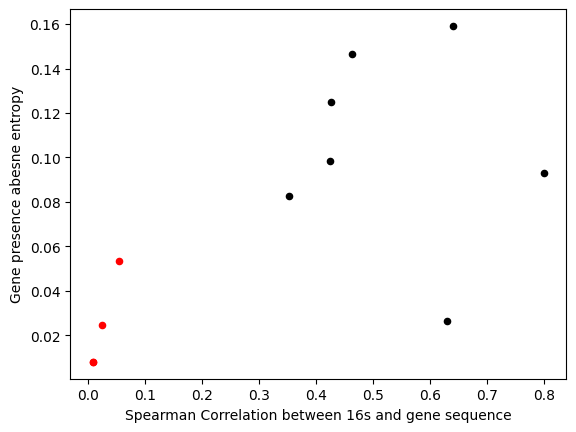

In [68]:
print(genes_select)

for i, gene in enumerate(gene_list):
    metrics[i, 1] = gene_averages[gene]
    if gene in set(genes_select):
        plt.scatter(metrics[i,1], metrics[i,1], s = 20, color = 'Red')
    else:
        plt.scatter(metrics[i,0], metrics[i,1], s = 20, color = 'Black')
    
plt.xlabel('Spearman Correlation between 16s and gene sequence')
plt.ylabel('Gene presence abesne entropy')


### Now combine files from various runs. 

In [31]:
import pandas as pd

#found genes
# Replace these with your actual file names
file1 = '../out/found_genes.csv'
file2 = '../out/found_genes_2.csv'
output_file = '../out/found_genes_combined.csv'

# Read both files, treating the first column as the index (organism)
df1 = pd.read_csv(file1, index_col=0)
df2 = pd.read_csv(file2, index_col=0)

# Concatenate along columns (axis=1), aligning by index (organism)
combined = pd.concat([df1, df2], axis=1)

# Save to CSV with organism as the first column (not as index)
combined.reset_index().to_csv(output_file, index=False)

print(f"Combined file saved as {output_file}")

#alignments

import sys
from pathlib import Path

# List your input files here (you can also pass them as command-line arguments)
input_files = [
    '../out/pairwise_alignments.csv',
    '../out/pairwise_alignments_2.csv',
]

# Alternatively, accept files from command line:
# input_files = sys.argv[1:]
# if not input_files: raise SystemExit("Usage: python merge_align.py file1.csv file2.csv ...")

# Start with the first file
df_merged = pd.read_csv(input_files[0])

# Use the first two columns as identifier keys
key_cols = ['species_1', 'species_2']

# Ensure the key columns exist
if not all(col in df_merged.columns for col in key_cols):
    raise ValueError(f"First file must contain columns: {key_cols}")

# Merge each subsequent file on the key columns
for file in input_files[1:]:
    df_next = pd.read_csv(file)
    # Check that key columns exist
    if not all(col in df_next.columns for col in key_cols):
        raise ValueError(f"File {file} missing key columns: {key_cols}")
    # Outer merge to keep all pairs; use 'how="outer"' or 'how="inner"' as needed
    df_merged = pd.merge(df_merged, df_next, on=key_cols, how='outer')

# Optional: sort columns so key columns come first, then genes alphabetically
gene_cols = sorted([col for col in df_merged.columns if col not in key_cols])
df_merged = df_merged[key_cols + gene_cols]

# Save result
output_file = '../out/pairwise_alignments_combined.csv'
df_merged.to_csv(output_file, index=False)

print(f"✅ Combined {len(input_files)} files into {output_file}")
print(f"   Rows: {len(df_merged)}, Columns: {len(df_merged.columns)}")

#next presence absence


# List your input files here, or pass them via command line
input_files = [
    '../out/denitrifier_variation.csv',
    '../out/denitrifier_variation_2.csv',
]

# Optional: use command-line arguments instead
# input_files = sys.argv[1:]
# if not input_files: raise SystemExit("Usage: python merge_genes.py file1.csv file2.csv ...")

# Define key columns that identify each row uniquely
key_cols = ['species', 'kegg_org', 'strain', 'description']

# Start with the first file
df_merged = pd.read_csv(input_files[0])

# Validate that key columns exist
missing_keys = [col for col in key_cols if col not in df_merged.columns]
if missing_keys:
    raise ValueError(f"First file missing key columns: {missing_keys}")

# Merge each additional file on the key columns
for file in input_files[1:]:
    df_next = pd.read_csv(file)
    missing_keys = [col for col in key_cols if col not in df_next.columns]
    if missing_keys:
        raise ValueError(f"File {file} missing key columns: {missing_keys}")
    
    # Outer merge: keep all strains from any file
    df_merged = pd.merge(df_merged, df_next, on=key_cols, how='outer')

# Optional: sort gene columns alphabetically after key columns
gene_cols = sorted([col for col in df_merged.columns if col not in key_cols])
df_merged = df_merged[key_cols + gene_cols]

# Save result
output_file = '../out/denitrifier_variation_combined.csv'
df_merged.to_csv(output_file, index=False)

print(f"✅ Merged {len(input_files)} files into {output_file}")
print(f"   Rows: {len(df_merged)}, Columns: {len(df_merged.columns)}")

Combined file saved as ../out/found_genes_combined.csv
✅ Combined 2 files into ../out/pairwise_alignments_combined.csv
   Rows: 57600, Columns: 17
✅ Merged 2 files into ../out/denitrifier_variation_combined.csv
   Rows: 386, Columns: 16
